In [ ]:
# Sesión 4 del módulo 9, clase 05/09
# Celda 0 — Instalación y sesión de Spark
# ============================================
# Instalación de PySpark y creación de SparkSession
# ============================================
!pip -q install pyspark

from pyspark.sql import SparkSession

# Creamos/obtenemos la sesión de Spark (punto de entrada a DataFrames y SQL)
spark = SparkSession.builder \
    .appName("AnalisisTransacciones") \
    .getOrCreate()

spark
# SparkSession.builder → inicializa el constructor de la sesión.
# .appName("AnalisisTransacciones") → asigna un nombre a la aplicación (sirve para identificar tu job en la interfaz de Spark, ej. http://localhost:4040
# ).
# .getOrCreate() →
# Si ya existe una sesión activa, la reutiliza.
# Si no, crea una nueva sesión.
# Esto evita errores de duplicación.
# En Jupyter/Colab, mostrar la variable spark imprime información de la sesión creada:
# Nombre de la app.
# Versión de Spark.
# Configuración (ejemplo: modo local, cantidad de hilos)

In [ ]:
# Crear dataset JSON de ejemplo (transacciones.json)
# ============================================
# Creamos un archivo JSON de prueba en /content
# (simula el dataset de transacciones de la guía)
# ============================================
json_text = """
[
  {"id": 1, "cliente": "Ana",    "monto": 150.75, "categoria": "Compras"},
  {"id": 2, "cliente": "Carlos", "monto": 230.50, "categoria": "Viajes"},
  {"id": 3, "cliente": "Elena",  "monto":  85.30, "categoria": "Alimentación"},
  {"id": 4, "cliente": "Miguel", "monto": 320.00, "categoria": "Electrónica"}
]
""".strip()
# Se define un string multilínea (""" ... """) que contiene datos en formato JSON.
# Cada elemento es un objeto JSON con 4 campos:
# id → identificador de la transacción.
# cliente → nombre de la persona.
# monto → valor numérico de la transacción.
# categoria → tipo de gasto.
# Al final se usa .strip() para eliminar espacios o saltos de línea al inicio y al final.
# En la práctica, este string simula lo que normalmente vendría en un archivo JSON real.

with open("/content/transacciones.json", "w", encoding="utf-8") as f:
    f.write(json_text)
# with open(..., "w", encoding="utf-8") → abre un archivo para escritura ("w"), en la carpeta /content (ruta típica en Google Colab).
# El bloque with asegura que el archivo se cierre automáticamente después de usarse.
# f.write(json_text) → escribe el contenido del string dentro del archivo transacciones.json.
# Así generas un archivo físico que luego Spark podrá leer con .read.json(...).

# Recomendación: si quieres ver el archivo crudo
!sed -n '1,120p' /content/transacciones.json
# El prefijo ! ejecuta comandos de Linux/Unix desde Colab/Jupyter.
# sed -n '1,120p' → imprime las líneas 1 a 120 del archivo (aunque aquí solo hay unas pocas).
# Sirve para verificar rápidamente que el archivo se creó correctamente y que los datos tienen el formato esperado.

[
  {"id": 1, "cliente": "Ana",    "monto": 150.75, "categoria": "Compras"},
  {"id": 2, "cliente": "Carlos", "monto": 230.50, "categoria": "Viajes"},
  {"id": 3, "cliente": "Elena",  "monto":  85.30, "categoria": "Alimentación"},
  {"id": 4, "cliente": "Miguel", "monto": 320.00, "categoria": "Electrónica"}
]

In [ ]:
# Cargar el JSON en un DataFrame y mostrar datos
# ============================================
# Lectura del JSON -> DataFrame de Spark
# Esta parte es donde Spark lee el archivo JSON que creaste y lo convierte en un DataFrame distribuido para poder trabajar con él.
# ============================================
df = spark.read.json("/content/transacciones.json")
# spark.read → es el lector de datos de Spark (soporta JSON, CSV, Parquet, bases de datos vía JDBC, etc.).
# .json("/content/transacciones.json") → le indica a Spark que el archivo está en formato JSON y que debe interpretarlo como tal.
# El resultado se guarda en df, que es un DataFrame de Spark.
# Un DataFrame de Spark es muy parecido a un DataFrame de pandas o a una tabla SQL, pero está distribuido: puede procesar millones de
# filas en paralelo sobre varios nodos.

# Mostrar las primeras filas
df.show(truncate=False)
# .show() → muestra las primeras 20 filas por defecto en formato de tabla.
# truncate=False → evita que Spark corte las cadenas largas (sin eso, puede mostrar "Alimen..." en vez de "Alimentación").
# Spark leyó el archivo transacciones.json.
# Detectó automáticamente las columnas (id, cliente, monto, categoria).
# Creó un DataFrame con esos datos estructurados.
# Al hacer .show(), puedes inspeccionar que la lectura fue correcta.

+---------------+------------+-------+----+------+
|_corrupt_record|categoria   |cliente|id  |monto |
+---------------+------------+-------+----+------+
|[              |NULL        |NULL   |NULL|NULL  |
|NULL           |Compras     |Ana    |1   |150.75|
|NULL           |Viajes      |Carlos |2   |230.5 |
|NULL           |Alimentación|Elena  |3   |85.3  |
|NULL           |Electrónica |Miguel |4   |320.0 |
|]              |NULL        |NULL   |NULL|NULL  |
+---------------+------------+-------+----+------+



In [ ]:
# Explorar el esquema (tipos de datos)
# ============================================
# Inspeccionar el esquema (columnas y tipos)
# Esta parte sirve para entender la estructura interna del DataFrame que Spark creó al leer el JSON.
# ============================================
df.printSchema()
# printSchema() muestra el esquema del DataFrame → es decir, los nombres de las columnas y sus tipos de datos detectados por Spark.

# Spark intenta inferir los tipos automáticamente leyendo los valores del archivo.

# Ejemplo con tu dataset:
# root
# |-- categoria: string (nullable = true)
# |-- cliente: string (nullable = true)
# |-- id: long (nullable = true)
# |-- monto: double (nullable = true)

# Significado:
# categoria → tipo string.
# cliente → tipo string.
# id → tipo long (entero grande).
# monto → tipo double (número decimal).
# nullable = true → Spark permite valores nulos en esas columnas.

# Opcional: conteo rápido
print("Filas:", df.count())

root
 |-- _corrupt_record: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- id: long (nullable = true)
 |-- monto: double (nullable = true)

Filas: 6


Esa salida significa que Spark, al leer tu JSON, detectó algo raro en los datos y creó una columna especial llamada _corrupt_record.
root
 |-- _corrupt_record: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- id: long (nullable = true)
 |-- monto: double (nullable = true)

Filas: 6
Interpretación
_corrupt_record

Esta columna aparece automáticamente cuando Spark encuentra líneas que no cumplen con el formato JSON esperado.

Es una especie de “contenedor de errores”: allí guarda el texto crudo de la línea problemática.

Si todo estuviera bien en el archivo, esa columna no debería existir.

Otras columnas (categoria, cliente, id, monto)

Estas son las que Spark sí pudo leer correctamente del JSON válido.

Todas aparecen con nullable = true porque Spark sabe que puede haber registros con valores faltantes.

Filas: 6

Significa que Spark encontró 6 registros en el archivo.

Como tu dataset original solo tenía 4 objetos JSON válidos, esto indica que hay 2 filas corruptas (posiblemente líneas vacías, comas sobrantes, o un error en la estructura JSON).

Esos registros se fueron a parar en la columna _corrupt_record.

La columna _corrupt_record es una señal de que hay errores de formato en el archivo JSON.

Spark intenta leer lo que puede: los registros válidos van a las columnas normales (id, cliente, etc.), y los registros dañados quedan en _corrupt_record.

El conteo de 6 filas indica que tienes más registros en el archivo de los esperados (4 válidos + 2 corruptos).

In [ ]:
# Registrar el DataFrame como vista SQL y consultar
# ============================================
# Registrar el DF como vista temporal (tabla virtual)
# ============================================
df.createOrReplaceTempView("transacciones")
# Convierte el DataFrame df en una vista temporal llamada "transacciones".
# Una vista temporal es como una tabla virtual: no se guarda en disco, solo vive durante la sesión de Spark.
# Esto te permite ejecutar consultas SQL estándar sobre los datos del DataFrame.

# Consulta SQL de ejemplo:
# Seleccionar cliente y monto donde el monto > 100
consulta = spark.sql("""
    SELECT cliente, monto
    FROM transacciones
    WHERE monto > 100
""")
# spark.sql(""" ... """) ejecuta una consulta SQL sobre las vistas registradas.
# La consulta en este caso selecciona dos columnas (cliente, monto) de la vista transacciones.
# WHERE monto > 100 filtra solo las filas donde el monto sea mayor que 100.
# Con tu dataset de ejemplo:
# {"id": 1, "cliente": "Ana",    "monto": 150.75, "categoria": "Compras"}
# {"id": 2, "cliente": "Carlos", "monto": 230.50, "categoria": "Viajes"}
# {"id": 3, "cliente": "Elena",  "monto":  85.30, "categoria": "Alimentación"}
# {"id": 4, "cliente": "Miguel", "monto": 320.00, "categoria": "Electrónica"}
# El resultado de la consulta será:
# Ana → 150.75
# Carlos → 230.50
# Miguel → 320.00
# (Elena no aparece porque su monto es 85.30, menor a 100).

consulta.show()
# .show() imprime el resultado de la consulta en formato de tabla.
# Por defecto muestra hasta 20 filas.

+-------+------+
|cliente| monto|
+-------+------+
|    Ana|150.75|
| Carlos| 230.5|
| Miguel| 320.0|
+-------+------+



In [ ]:
# UDF (Función Definida por el Usuario) para clasificar montos
# ============================================
# Crear y aplicar una UDF para clasificar transacciones por monto
# ============================================
# ============================================
# Celda 5 (versión sin UDF): clasificar montos con funciones nativas

# Esta parte del código sirve para clasificar las transacciones según el valor del campo monto, pero en vez de usar una UDF personalizada (que es más lenta),
# se usan las funciones nativas de Spark SQL, que son más rápidas y seguras
# ============================================
from pyspark.sql.functions import col, when
# col("nombre_columna") → referencia una columna dentro de un DataFrame.
# when(condición, valor) → equivale a un IF o CASE WHEN en SQL. Permite crear condiciones sobre columnas.

# Aseguramos tipo numérico por si el JSON trae strings
# Asegurar que la columna monto sea numérica
df_typed = df.withColumn("monto", col("monto").cast("double"))
# .withColumn("monto", ...) → crea (o reemplaza) la columna monto.
# .cast("double") → convierte los valores de monto a tipo numérico decimal (double).
# Esto se hace porque a veces Spark al leer JSON o CSV infiere mal el tipo (por ejemplo, lo deja como string).
# Resultado: ahora monto es 150.75, 230.50, 85.30, etc., en tipo double.

# Clasificación segura ante nulos:
# Crear nueva columna con la clasificación
# - si monto es null -> null (o "Desconocido", si prefieres)
# - si monto > 200 -> "Alta"
# - en caso contrario -> "Baja"
df_transformado = (
    df_typed
    .withColumn(
        "categoria_monto",
        when(col("monto").isNull(), None)
        .when(col("monto") > 200, "Alta")
        .otherwise("Baja")
    )
)
# .withColumn("categoria_monto", ...) → agrega una nueva columna llamada categoria_monto.
# La lógica de clasificación es:
# Nulo → None (puedes cambiarlo por "Desconocido" si prefieres).
# Mayor a 200 → "Alta".
# Menor o igual a 200 → "Baja".
# Ejemplo con tu dataset:
# Ana → 150.75 → "Baja".
# Carlos → 230.50 → "Alta".
# Elena → 85.30 → "Baja".
# Miguel → 320.00 → "Alta".

df_transformado.show(truncate=False)
# Esto imprime la tabla completa sin cortar cadenas.
# Ejemplo de salida:

# +---+-------+------+------------+---------------+
# |id |cliente|monto |categoria   |categoria_monto|
# +---+-------+------+------------+---------------+
# |1  |Ana    |150.75|Compras     |Baja           |
# |2  |Carlos |230.5 |Viajes      |Alta           |
# |3  |Elena  |85.3  |Alimentación|Baja           |
# |4  |Miguel |320.0 |Electrónica |Alta           |
# +---+-------+------+------------+---------------+

df_transformado.printSchema()
# Muestra la estructura con la nueva columna:
# root
# |-- id: long (nullable = true)
# |-- cliente: string (nullable = true)
# |-- monto: double (nullable = true)
# |-- categoria: string (nullable = true)
# |-- categoria_monto: string (nullable = true)


+---------------+------------+-------+----+------+---------------+
|_corrupt_record|categoria   |cliente|id  |monto |categoria_monto|
+---------------+------------+-------+----+------+---------------+
|[              |NULL        |NULL   |NULL|NULL  |NULL           |
|NULL           |Compras     |Ana    |1   |150.75|Baja           |
|NULL           |Viajes      |Carlos |2   |230.5 |Alta           |
|NULL           |Alimentación|Elena  |3   |85.3  |Baja           |
|NULL           |Electrónica |Miguel |4   |320.0 |Alta           |
|]              |NULL        |NULL   |NULL|NULL  |NULL           |
+---------------+------------+-------+----+------+---------------+

root
 |-- _corrupt_record: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- id: long (nullable = true)
 |-- monto: double (nullable = true)
 |-- categoria_monto: string (nullable = true)



Columna _corrupt_record

Es generada automáticamente por Spark cuando intenta leer un JSON mal formateado.

Aquí se ve que dos filas están “rotas”:

La primera contiene un [ (apertura del array JSON).

La última contiene un ] (cierre del array JSON).

Spark no sabe cómo interpretar esas líneas como registros válidos, así que las manda a _corrupt_record.

Filas válidas (las del medio)

Estas sí corresponden a objetos JSON bien estructurados.

Spark las interpretó correctamente y les asignó valores a las columnas categoria, cliente, id, monto, categoria_monto.

Columnas con valores NULL

En las filas corruptas (primera y última), todas las demás columnas (categoria, cliente, id, monto, etc.) aparecen como NULL porque no se pudieron parsear.

El esquema
root
 |-- _corrupt_record: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- id: long (nullable = true)
 |-- monto: double (nullable = true)
 |-- categoria_monto: string (nullable = true)


Spark creó la columna _corrupt_record para atrapar esas filas dañadas.

El resto de las columnas son las que definió al analizar los objetos JSON válidos.

En resumen

La salida significa que:

Tu archivo JSON no está en formato “newline-delimited” (JSON por línea), sino como un array [...].

Spark interpretó cada línea por separado: las líneas con solo [ o ] se consideran “corruptas”.

Por eso tienes 6 filas en total: 4 válidas y 2 corruptas.

In [ ]:
# Guardar resultados en formato Parquet
# ============================================
# Escribir el DataFrame transformado en formato Parquet
# - Parquet es columnar, comprimido y eficiente para análisis
# Esta parte del código trata de guardar los resultados procesados en un formato optimizado (Parquet) y luego volver a leerlos para verificar
# ============================================
output_dir = "/content/transacciones_procesadas.parquet"
# Aquí se indica dónde se guardará el archivo en Colab (/content/ es la carpeta principal).
# Aunque se llama “archivo”, en realidad Spark genera una carpeta con varios archivos internos (porque los datos se pueden particionar).

# mode="overwrite" para reescribir si ejecutas varias veces
# Guardar en formato Parquet
df_transformado.write.mode("overwrite").parquet(output_dir)
# df_transformado.write → accede al escritor de DataFrames.
# .mode("overwrite") → si ya existe esa carpeta/archivo, lo sobrescribe (útil en Colab para no acumular duplicados).
# .parquet(output_dir) → guarda el DataFrame en formato Parquet.
# ¿Qué es Parquet?
# Es un formato de almacenamiento columnar.
# Ventajas:
# Comprime datos de manera eficiente.
# Es más rápido para leer columnas específicas (no necesita cargar toda la fila).
# Se usa muchísimo en Big Data y Data Lakes (ej. Hadoop, AWS S3, Azure).

print("Parquet escrito en:", output_dir)
# Esto solo imprime un mensaje con la ruta donde quedó almacenado el dataset.

# Leer de vuelta para verificar
df_check = spark.read.parquet(output_dir)
# Vuelve a leer el dataset guardado en formato Parquet.
# Esto comprueba que el archivo no solo se guardó, sino que también puede cargarse nuevamente en Spark sin problemas.
df_check.show(truncate=False)
df_check.printSchema()
# .show(truncate=False) → imprime el contenido del DataFrame leído.
# .printSchema() → muestra las columnas y sus tipos de datos, confirmando que se mantienen igual que en df_transformado.


Parquet escrito en: /content/transacciones_procesadas.parquet
+---------------+------------+-------+----+------+---------------+
|_corrupt_record|categoria   |cliente|id  |monto |categoria_monto|
+---------------+------------+-------+----+------+---------------+
|[              |NULL        |NULL   |NULL|NULL  |NULL           |
|NULL           |Compras     |Ana    |1   |150.75|Baja           |
|NULL           |Viajes      |Carlos |2   |230.5 |Alta           |
|NULL           |Alimentación|Elena  |3   |85.3  |Baja           |
|NULL           |Electrónica |Miguel |4   |320.0 |Alta           |
|]              |NULL        |NULL   |NULL|NULL  |NULL           |
+---------------+------------+-------+----+------+---------------+

root
 |-- _corrupt_record: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- id: long (nullable = true)
 |-- monto: double (nullable = true)
 |-- categoria_monto: string (nullable = true)



In [ ]:
# (Opcional) Leer desde MySQL vía JDBC
# ============================================
# EJEMPLO JDBC (Opcional)
# Reemplaza los valores con tu servidor/base reales.
# Esa parte del código muestra cómo conectar Spark con una base de datos MySQL usando JDBC (Java Database Connectivity).
# ============================================

mysql_url = "jdbc:mysql://localhost:3306/mi_base?useSSL=false&serverTimezone=UTC"
mysql_table = "transacciones"   # nombre de la tabla en MySQL
mysql_user = "root"
mysql_pass = "1234"
# mysql_url → la URL de conexión JDBC:
# jdbc:mysql://localhost:3306/mi_base → se conecta al servidor MySQL que corre en localhost (puerto 3306) y a la base de datos mi_base.
# useSSL=false → desactiva SSL (útil para entornos locales).
# serverTimezone=UTC → asegura que Spark interprete bien la zona horaria.
# mysql_table → la tabla que quieres leer dentro de MySQL (transacciones).
# mysql_user y mysql_pass → credenciales de acceso a la base de datos.

# Si tienes el conector .jar, podrías necesitar algo como:
# spark.sparkContext.addPyFile("/content/mysql-connector-j-8.4.0.jar")
# o configurar spark.jars.packages al crear la SparkSession.
# Spark no puede hablar con MySQL “de fábrica”.

# Necesita el driver JDBC de MySQL (mysql-connector-j-x.x.x.jar).
# Aquí se muestra cómo agregar el .jar si ya lo tienes descargado en /content/.

# Descomenta para probar si tienes un MySQL disponible:
# df_mysql = (spark.read
#             .format("jdbc")
#             .option("url", mysql_url)
#             .option("dbtable", mysql_table)
#             .option("user", mysql_user)
#             .option("password", mysql_pass)
#             # .option("driver", "com.mysql.cj.jdbc.Driver")  # si es necesario
#             .load())
# df_mysql.show()
# .format("jdbc") → indica que la fuente es JDBC.
# .option("url", mysql_url) → URL de conexión.
# .option("dbtable", mysql_table) → tabla a leer.
# .option("user", mysql_user) y .option("password", mysql_pass) → credenciales.
# .option("driver", "com.mysql.cj.jdbc.Driver") → especifica el driver (a veces obligatorio).
# .load() → ejecuta la carga de datos desde MySQL a un DataFrame de Spark.
# Luego df_mysql.show() mostraría las primeras filas de la tabla transacciones directamente desde MySQL.

In [ ]:
# (Opcional) Variantes: lectura CSV y exportar a JSON/CSV
# ============================================
# Otras variantes útiles para clase
# Esa parte del código muestra variantes de entrada/salida de datos en Spark, muy útiles para clase porque te permiten practicar con
# distintos formatos además de JSON/Parquet.
# ============================================

# 1) Leer CSV con encabezado y esquema inferido
# csv_df = (spark.read
#           .option("header", True)
#           .option("inferSchema", True)
#           .csv("/content/transacciones.csv"))
# spark.read.csv(...) → lee un archivo CSV.
# .option("header", True) → indica que la primera fila contiene los nombres de las columnas (si no, Spark pondrá _c0, _c1, _c2...).
# .option("inferSchema", True) → le pide a Spark que deduzca automáticamente los tipos de datos (ej: monto como double, id como int).
# El resultado se guarda en un DataFrame llamado csv_df.
# Muy útil cuando quieres comparar lectura de JSON vs CSV.

# 2) Guardar como JSON (carpeta con archivos-partición)
# df_transformado.write.mode("overwrite").json("/content/transacciones_procesadas.json")
# df_transformado.write → accede al escritor de DataFrames.
# .mode("overwrite") → sobreescribe la carpeta si ya existe.
# .json("ruta") → guarda los datos en formato JSON.
# Ojo: Spark no genera un solo archivo JSON, sino una carpeta con múltiples archivos part-xxxxx.json, porque los datos están particionados (distribuidos).

# 3) Guardar como CSV
# df_transformado.write.mode("overwrite").option("header", True).csv("/content/transacciones_procesadas.csv")
# .csv("ruta") → exporta en formato CSV.
# .option("header", True) → incluye la fila de encabezado (nombres de columnas).
# .mode("overwrite") → sobreescribe si ya existe.
# Igual que con JSON, Spark genera una carpeta con varios part-xxxxx.csv, no un único archivo, porque cada “part” corresponde a una partición de los datos.

In [ ]:
# (Opcional) Cerrar la sesión de Spark
# ============================================
# Cerrar Spark cuando termines (libera recursos)
# ============================================
spark.stop()
# spark.stop() → apaga la SparkSession y, con ella, el SparkContext que estaba en ejecución.
# Esto libera todos los recursos que Spark estaba usando: memoria RAM, hilos de CPU, conexiones abiertas, etc.

# ¿Por qué es importante?
# En entornos como Colab o Jupyter, si dejas Spark corriendo sin usarlo, consume memoria y CPU innecesariamente.
# En entornos de clusters reales (ej. Hadoop/YARN, Kubernetes, Databricks), no cerrar Spark significa mantener recursos bloqueados para tu aplicación,
# afectando a otros usuarios.
# Es buena práctica cerrar siempre al final del notebook o script, igual que cerrar una conexión a base de datos.

In [ ]:
# Más ejemplos
# ============================================
# Configuración básica: SparkSession y SparkContext
# ============================================
!pip -q install pyspark

from pyspark.sql import SparkSession

# Creamos la SparkSession
spark = SparkSession.builder \
    .appName("SesionElementosBasicos") \
    .getOrCreate()

# Obtenemos el SparkContext (nivel más bajo de Spark)
sc = spark.sparkContext

print("AppName:", sc.appName)
print("Master:", sc.master)  # por defecto "local[*]" en Colab
print("Version:", sc.version)

AppName: SesionElementosBasicos
Master: local[*]
Version: 3.5.1


In [ ]:
# ============================================
# Crear un RDD desde una lista
# ============================================
datos = [1, 2, 3, 4, 5, 6, 7, 8, 9]
# Aquí tenemos una lista normal de Python con números del 1 al 9.
# Todavía no está distribuida, es solo un objeto en el driver (tu sesión de Colab o Jupyter).

# Convertir la lista en un RDD
rdd = sc.parallelize(datos)  # distribuye la lista como RDD
# sc es el SparkContext, el objeto de bajo nivel que controla Spark.
# .parallelize(lista) convierte la lista de Python en un RDD (Resilient Distributed Dataset).
# El RDD es una colección distribuida: Spark puede dividirla en particiones y repartirla entre nodos (aunque en Colab es todo local).
# A partir de aquí, puedes usar operaciones de Spark (map, filter, reduce, etc.) sobre rdd.

print("RDD:", rdd)
# Esto no imprime los datos, sino una referencia interna de Spark, algo como:
# RDD: ParallelCollectionRDD[0] at parallelize at PythonRDD.scala:...
# Esa salida significa:
# ParallelCollectionRDD → se creó a partir de una colección en memoria.
# El número entre corchetes ([0]) es el ID del RDD.
# El resto indica en qué parte de Spark se originó.

print("Primeros 5 elementos:", rdd.take(5))
# .take(n) es una acción que devuelve los primeros n elementos del RDD como lista de Python.
# En este caso:
# Primeros 5 elementos: [1, 2, 3, 4, 5]
# Esto confirma que el RDD contiene los números de la lista original.

RDD: ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.scala:289
Primeros 5 elementos: [1, 2, 3, 4, 5]


In [ ]:
# ============================================
# Guardar y leer RDD desde un archivo
# ============================================
# Guardamos los datos como texto
rdd.saveAsTextFile("/content/rdd_numeros")
# .saveAsTextFile(ruta) → guarda el contenido del RDD como archivos de texto.
# En Colab (o en Linux en general) /content/ es una carpeta válida.
# Spark no guarda un solo archivo, sino un directorio que contiene:
# Archivos tipo part-00000, part-00001… (uno por partición).
# Un _SUCCESS indicando que la escritura terminó bien.
# Ejemplo: si tu RDD tenía [1,2,3,4,5] y 2 particiones, verías algo como:

# /content/rdd_numeros/
# ├── part-00000
# ├── part-00001
# └── _SUCCESS
#

# Volvemos a cargarlo desde el directorio creado
rdd2 = sc.textFile("/content/rdd_numeros")
# sc.textFile(ruta) → carga todos los archivos de texto que están dentro de esa carpeta en un nuevo RDD.
# Cada línea de los archivos se convierte en un string en el RDD.
# O sea, si guardaste [1,2,3,4,5], ahora tendrás ["1","2","3","4","5"].
# (nota: los números ya no son enteros, sino cadenas de texto).

print("RDD leído desde archivo:", rdd2.collect())
# .collect() es una acción: trae todos los elementos del RDD de vuelta al driver (tu notebook).
# La salida será:
# RDD leído desde archivo: ['1', '2', '3', '4', '5']

RDD leído desde archivo: ['5', '6', '7', '8', '9', '1', '2', '3', '4']


¿Por qué no salió en el mismo orden [1,2,3,4,5,6,7,8,9]?

Al guardar el RDD (saveAsTextFile)

Spark divide el RDD en particiones (chunks de datos).

Cada partición se escribe en un archivo separado (part-00000, part-00001, etc.).

Ejemplo:

part-00000 → puede contener [5,6,7,8,9].

part-00001 → puede contener [1,2,3,4].

Al leer con sc.textFile()

Spark vuelve a armar el RDD leyendo partición por partición.

Pero el orden entre particiones no está garantizado.

Por eso primero viste ['5','6','7','8','9'] (una partición) y luego ['1','2','3','4'] (la otra).

Entonces, ¿qué significa la salida?

Spark sí guardó todos los datos correctamente.

Pero el orden de las filas no se conserva necesariamente después de un saveAsTextFile + textFile.

El resultado puede variar según:

el número de particiones,

el orden en que Spark lea los archivos part-*,

incluso la configuración del cluster.

In [ ]:
# ============================================
# Crear un Pair RDD (clave, valor)
# contar ocurrencias usando un Pair RDD (clave, valor)
# ============================================
nombres = ["Ana", "Luis", "Ana", "Pedro", "Luis", "Ana"]
rdd_nombres = sc.parallelize(nombres)
# Creamos una lista con algunos nombres repetidos.
# sc.parallelize(...) la convierte en un RDD distribuido.
# Ahora rdd_nombres contiene:
# ["Ana", "Luis", "Ana", "Pedro", "Luis", "Ana"]

# Creamos pares (nombre, 1) para contarlos
pair_rdd = rdd_nombres.map(lambda x: (x, 1))
# Cada nombre se convierte en una tupla (nombre, 1).
# Esto se llama un Pair RDD, porque cada elemento tiene una clave (el nombre) y un valor (el número 1).
# Ejemplo de salida después del map:
# [("Ana", 1), ("Luis", 1), ("Ana", 1), ("Pedro", 1), ("Luis", 1), ("Ana", 1)]

# Contamos ocurrencias por clave
conteo = pair_rdd.reduceByKey(lambda a, b: a + b)
# reduceByKey agrupa los elementos con la misma clave (nombre).
# Aplica la función lambda a, b: a + b para sumar los valores de cada clave.
# Ejemplo:
# Para "Ana" → (1 + 1 + 1) = 3.
# Para "Luis" → (1 + 1) = 2.
# Para "Pedro" → 1.
# El resultado es un nuevo RDD con los pares contados:
# [("Ana", 3), ("Luis", 2), ("Pedro", 1)]

print("Conteo de nombres:", conteo.collect())
# .collect() trae todos los datos del RDD de vuelta al driver (Python local).
# La salida será:
# Conteo de nombres: [('Ana', 3), ('Luis', 2), ('Pedro', 1)]

Conteo de nombres: [('Luis', 2), ('Pedro', 1), ('Ana', 3)]


Cada elemento de la lista es de la forma (nombre, cantidad):

('Luis', 2) → el nombre Luis apareció 2 veces en la lista original.

('Pedro', 1) → el nombre Pedro apareció 1 vez.

('Ana', 3) → el nombre Ana apareció 3 veces.

Relación con los datos originales

Tu lista inicial era:

["Ana", "Luis", "Ana", "Pedro", "Luis", "Ana"]


Ana → aparece en las posiciones 0, 2 y 5 → 3 veces.

Luis → aparece en las posiciones 1 y 4 → 2 veces.

Pedro → aparece en la posición 3 → 1 vez.

Por eso el resultado es exactamente:

[('Luis', 2), ('Pedro', 1), ('Ana', 3)]

¿Por qué no están ordenados?

Spark no garantiza orden en el resultado de un RDD después de un reduceByKey.

El orden que ves (Luis, Pedro, Ana) depende de cómo Spark procesó las particiones.

In [ ]:
# ============================================
# Linaje: ver el DAG de transformaciones
# Este bloque muestra uno de los conceptos más importantes de Spark: lazy evaluation y el linaje (DAG de transformaciones).
# ============================================
rdd_base = sc.parallelize([1, 2, 3, 4, 5])
# Crea un RDD con los números [1,2,3,4,5].
# Aún no hay ninguna acción, solo está el dataset distribuido.
rdd_filtrado = rdd_base.filter(lambda x: x > 2)  # transformación
# filter es una transformación: Spark marca que debe filtrar los elementos mayores que 2.
# Resultado lógico (aunque aún no ejecutado): [3,4,5].
# Importante: aquí Spark no procesa nada todavía, solo construye el plan de ejecución.
rdd_cuadrado = rdd_filtrado.map(lambda x: x**2)  # otra transformación
# map aplica la función x**2 a cada elemento.
# Resultado lógico: [9,16,25].
# Nuevamente, Spark todavía no lo calcula.

# Hasta aquí Spark no ejecuta nada (lazy evaluation).
# Solo cuando hacemos una acción, se dispara el "job".
print("Resultado final:", rdd_cuadrado.collect())
# .collect() es una acción.
# En este momento Spark:
# Recorre todo el linaje (desde rdd_base).
# Ejecuta las transformaciones filter y map.
# Devuelve el resultado al driver (Python).
# Salida:
# Resultado final: [9, 16, 25]

# Ver el linaje del RDD
print("Linaje de rdd_cuadrado:")
print(rdd_cuadrado.toDebugString().decode("utf-8"))
# .toDebugString() muestra el linaje completo del RDD, es decir, la secuencia de transformaciones que Spark tiene que ejecutar para producirlo.
# Ejemplo de salida típica:
# (2) PythonRDD[3] at collect at ...
# |  MapPartitionsRDD[2] at map at ...
# |  MapPartitionsRDD[1] at filter at ...
# |  ParallelCollectionRDD[0] at parallelize at ...


# Significado:
# ParallelCollectionRDD[0] → el RDD inicial creado con parallelize.
# MapPartitionsRDD[1] → resultado de aplicar el filter.
# MapPartitionsRDD[2] → resultado de aplicar el map.
# PythonRDD[3] → el RDD final que Spark evaluará cuando hagas la acción.
# Los números [0], [1], [2]... son los identificadores de cada RDD.
# Los | muestran la jerarquía: cómo cada RDD depende del anterior.

Resultado final: [9, 16, 25]
Linaje de rdd_cuadrado:
(2) PythonRDD[15] at collect at /tmp/ipython-input-2081880517.py:10 []
 |  ParallelCollectionRDD[14] at readRDDFromFile at PythonRDD.scala:289 []


1) Resultado final: [9, 16, 25]

Corresponde a este pipeline:

rdd_base = [1,2,3,4,5]

filter(lambda x: x > 2) → [3,4,5]

map(lambda x: x**2) → [9,16,25]

Como Spark es lazy, recién al hacer collect() ejecuta todo y devuelve esos tres valores.

2) Linaje (DAG) que te muestra Spark
Linaje de rdd_cuadrado:
(2) PythonRDD[15] at collect at /tmp/ipython-input-2081880517.py:10 []
 |  ParallelCollectionRDD[14] at readRDDFromFile at PythonRDD.scala:289 []


Qué significa:

ParallelCollectionRDD[14]
Es el RDD origen (creado con parallelize o leído). Representa la colección inicial desde la que parte el cálculo.

PythonRDD[15]
Es el RDD resultante que Spark ejecuta antes de la acción (collect).
En PySpark, varias transformaciones “estrechas” (narrow) como filter y map se pipelinean dentro de un mismo tramo; por eso ves un único PythonRDD que “envuelve” la cadena de transformaciones.

¿Y los map/filter que no aparecen?
En Spark 3.x es normal que toDebugString compacte transformaciones estrechas en menos nodos (pipelining). Por eso no siempre verás líneas como MapPartitionsRDD[...] para cada paso. Están ahí, pero fusionadas en la ejecución del mismo stage.

El prefijo (2)
Indica el número de particiones (o el “level” que Spark muestra en ese momento). No es un “job id”; es metadato del RDD mostrado.

In [ ]:
# ============================================
# Ejemplos de transformaciones
# ejemplos prácticos de transformaciones en Spark RDDs.
# ============================================
rdd = sc.parallelize([1, 2, 2, 3, 4, 5, 6])
# Tenemos un RDD con los números [1, 2, 2, 3, 4, 5, 6].
# Notar que hay un 2 repetido

print("filter (>3):", rdd.filter(lambda x: x > 3).collect())
# filter → mantiene solo los elementos que cumplan la condición x > 3.
# Resultado: [4, 5, 6]
print("map (x*2):", rdd.map(lambda x: x*2).collect())
# map → aplica la función x*2 a cada elemento.
# Resultado: [2, 4, 4, 6, 8, 10, 12]
print("flatMap (expande):", rdd.flatMap(lambda x: (x, x*10)).collect())
# flatMap → cada elemento puede transformarse en cero, uno o varios elementos.
# Aquí cada número genera dos valores: (x, x*10).
# Resultado: [1, 10, 2, 20, 2, 20, 3, 30, 4, 40, 5, 50, 6, 60]
print("sample:", rdd.sample(False, 0.5, seed=42).collect())
# sample(withReplacement, fraction, seed)
# withReplacement=False → sin reemplazo.
# fraction=0.5 → aprox. 50% de los elementos.
# seed=42 → semilla para reproducibilidad.
# Ejemplo de salida: [2, 3, 4] (puede variar si cambias el seed).
print("union:", rdd.union(sc.parallelize([7, 8])).collect())
# Une dos RDDs en uno solo (no elimina duplicados).
# Resultado: [1, 2, 2, 3, 4, 5, 6, 7, 8]
print("distinct:", rdd.distinct().collect())
# Elimina elementos repetidos.
# Resultado: [1, 2, 3, 4, 5, 6]
print("sortBy descendente:", rdd.sortBy(lambda x: -x).collect())
# Ordena los elementos usando una clave de ordenamiento.
# Aquí se usa -x para obtener orden descendente.
# Resultado: [6, 5, 4, 3, 2, 2, 1]

filter (>3): [4, 5, 6]
map (x*2): [2, 4, 4, 6, 8, 10, 12]
flatMap (expande): [1, 10, 2, 20, 2, 20, 3, 30, 4, 40, 5, 50, 6, 60]
sample: [1, 2]
union: [1, 2, 2, 3, 4, 5, 6, 7, 8]
distinct: [2, 4, 6, 1, 3, 5]
sortBy descendente: [6, 5, 4, 3, 2, 2, 1]


In [ ]:
# ============================================
# Ejemplos de acciones
# Ese bloque muestra acciones en Spark, que son las operaciones que ejecutan de verdad el DAG de transformaciones y traen un resultado
# al driver (tu programa en Python).
# ============================================
rdd = sc.parallelize([10, 20, 30, 40, 50])
# Se distribuye la lista [10, 20, 30, 40, 50] como un RDD.
# Hasta aquí no se ha hecho ningún cálculo real.

print("collect:", rdd.collect())
# Acción que trae todos los elementos del RDD como una lista de Python.
# Salida:
# collect: [10, 20, 30, 40, 50]
print("take(3):", rdd.take(3))
# Devuelve los n elementos más grandes (en orden descendente).
# Salida:
# top(2): [50, 40]
# Devuelve los primeros n elementos del RDD.
# Salida:
# take(3): [10, 20, 30]
print("top(2):", rdd.top(2))
print("takeSample(False, 3):", rdd.takeSample(False, 3, seed=1))
# Devuelve una muestra aleatoria de n elementos.
# withReplacement=False → sin reemplazo.
# seed=1 → fija la semilla para reproducibilidad.
# Ejemplo de salida:
# takeSample(False, 3): [50, 20, 40]
print("sum:", rdd.sum())
# Devuelve la suma de todos los elementos.
# Salida:
# sum: 150
print("mean:", rdd.mean())
# Devuelve la media aritmética de los elementos.
# Cálculo: (10+20+30+40+50)/5 = 30.0
print("stdev:", rdd.stdev())
# Devuelve la desviación estándar muestral de los elementos

collect: [10, 20, 30, 40, 50]
take(3): [10, 20, 30]
top(2): [50, 40]
takeSample(False, 3): [30, 40, 50]
sum: 150
mean: 30.0
stdev: 14.142135623730951


In [ ]:
# Qué es un Job en Spark
# ============================================
# Un "job" se lanza cada vez que haces una acción.
# En Spark, un Job es la unidad de trabajo que se ejecuta cada vez que lanzas una acción (collect, count, take, saveAsTextFile, etc.).
# Las transformaciones (map, filter, flatMap, reduceByKey) son lazy → no hacen nada hasta que llega una acción.
# Cuando llamas a una acción, Spark arma un DAG de transformaciones y lo ejecuta como un Job, dividiéndolo en stages y tasks.
# Ejemplo: contar palabras en un texto.
texto = ["hola spark", "hola mundo", "spark es genial"]
rdd_texto = sc.parallelize(texto)
# Tenemos una lista de cadenas de texto.
# El RDD rdd_texto contiene 3 elementos:
# ["hola spark", "hola mundo", "spark es genial"]

# FlatMap -> divide en palabras
# Map -> crea pares (palabra, 1)
# ReduceByKey -> suma por palabra
conteo_palabras = rdd_texto.flatMap(lambda l: l.split(" ")) \
                           .map(lambda p: (p, 1)) \
                           .reduceByKey(lambda a, b: a + b)
# flatMap(lambda l: l.split(" "))
# Divide cada línea en palabras →
# ["hola", "spark", "hola", "mundo", "spark", "es", "genial"]
# map(lambda p: (p, 1))
# Convierte cada palabra en un par (palabra, 1) →
# [("hola",1), ("spark",1), ("hola",1), ("mundo",1), ("spark",1), ("es",1), ("genial",1)]
# reduceByKey(lambda a, b: a + b)
# Agrupa por clave (palabra) y suma los valores:
# [("hola",2), ("spark",2), ("mundo",1), ("es",1), ("genial",1)]

print("Conteo de palabras:", conteo_palabras.collect())
# .collect() es una acción → Spark dispara un Job.
# En ese momento se ejecuta todo el pipeline (flatMap → map → reduceByKey).
# Salida:
# Conteo de palabras: [('hola', 2), ('spark', 2), ('mundo', 1), ('es', 1), ('genial', 1)]

Conteo de palabras: [('mundo', 1), ('es', 1), ('genial', 1), ('hola', 2), ('spark', 2)]


Cada elemento de la lista es de la forma (palabra, cantidad):

('mundo', 1) → la palabra "mundo" apareció 1 vez.

('es', 1) → la palabra "es" apareció 1 vez.

('genial', 1) → la palabra "genial" apareció 1 vez.

('hola', 2) → la palabra "hola" apareció 2 veces.

('spark', 2) → la palabra "spark" apareció 2 veces.

Relación con el texto original

Tus datos de entrada eran:

["hola spark", "hola mundo", "spark es genial"]

Si lo dividimos en palabras:

["hola", "spark", "hola", "mundo", "spark", "es", "genial"]

hola → aparece 2 veces.

spark → aparece 2 veces.

mundo → aparece 1 vez.

es → aparece 1 vez.

genial → aparece 1 vez.

Esto coincide exactamente con la salida.

¿Por qué el orden es distinto?

Spark no garantiza que el resultado de un reduceByKey venga ordenado.

Por eso ves las palabras en un orden arbitrario: mundo, es, genial, hola, spark.

In [ ]:
# Ejemplo versión visual con gráficos DAG (usando toDebugString y explicando stages/tasks) para que los alumnos vean cómo
# Spark divide el trabajo internamente.
# Ver la URL del Spark UI (jobs, stages, tasks)
# ============================================
# En Colab suele exponer el UI por un túnel interno; imprime lo que Spark reporta.
# Si no aparece un enlace clicable, al menos verás la URL local que Spark intenta usar.
print("Spark UI:", spark.sparkContext.uiWebUrl)
# Muestra la dirección del panel de Spark (Jobs, Stages, Tasks, Storage, etc.).
# En Colab a veces no aparece clicable o puede ser None; si sale una URL, ábrela para ver cómo se ejecuta tu job.

# Recordatorio: cada ACCIÓN (collect, count, take, save...) dispara un JOB.
# Para verlo en el UI, ejecuta una acción tras algunas transformaciones:
base = spark.sparkContext.parallelize([("a",1),("a",2),("b",3),("b",4)])
res = (base
       .map(lambda kv: (kv[0], kv[1]*10))
       .filter(lambda kv: kv[1] > 10)
       .reduceByKey(lambda a,b: a+b))   # <-- provoca shuffle -> nuevo stage
# map y filter son transformaciones estrechas (narrow): cada partición solo lee su partición “madre”. Van en el mismo stage.
# reduceByKey es ancha (wide): necesita reagrupar por clave → shuffle → corta el stage y crea otro stage.

print("Acción -> collect:", res.collect())
# collect() es una acción ⇒ Spark ejecuta el Job completo (todos los stages).

# Resultado esperado (orden no garantizado):
# map: (a,10),(a,20),(b,30),(b,40)
# filter (>10): (a,20),(b,30),(b,40)
# reduceByKey: ('a', 20) y ('b', 70)
# Verás algo como: Acción -> collect: [('a', 20), ('b', 70)]

# Qué verás en el Spark UI
# Jobs: 1 job (por el collect()).
# Stages: normalmente 2 stages:
# Stage del map + filter (narrow).
# Stage del reduceByKey (wide, con shuffle).
# Tasks: una por partición en cada stage (el número puede variar según tu paralelo por defecto).
# DAG Visualization: un grafo donde el borde entre filter/map y reduceByKey marca el shuffle (cambio de stage).

Spark UI: http://9a24a68b81e6:4040
Acción -> collect: [('b', 70), ('a', 20)]


In [ ]:
# ============================================
# Ver el linaje (DAG) textual con toDebugString
# Este código sirve para visualizar el linaje (DAG) de un RDD en Spark y mostrar cómo se organizan las transformaciones en stages.
# ============================================
rdd0 = spark.sparkContext.parallelize(range(1, 11), 2)   # 2 particiones
# Se crea un RDD con los números del 1 al 10.
# ,2 significa que Spark lo divide en 2 particiones (2 “pedazos” de datos
rdd1 = rdd0.map(lambda x: (x % 3, x))                    # (clave, valor)
# Cada número se transforma en un par (x % 3, x).
# Ejemplo: 1 → (1,1), 2 → (2,2), 3 → (0,3).
# Ahora tenemos un Pair RDD con clave = residuo de dividir por 3.
rdd2 = rdd1.filter(lambda kv: kv[1] > 3)
# Se eliminan los pares cuya parte x sea ≤ 3.
# Resultado lógico: se quedan los valores del 4 al 10.
rdd3 = rdd2.reduceByKey(lambda a, b: a + b)              # wide dep. (shuffle)
# Agrupa por clave (residuo mod 3) y suma los valores.
# Como es un wide dependency (requiere shuffle de datos entre particiones), aquí Spark corta el stage.
# Ejemplo lógico:
# Clave 1: valores = [4,7,10] → suma = 21
# Clave 2: valores = [5,8] → suma = 13
# Clave 0: valores = [6,9] → suma = 15
rdd4 = rdd3.mapValues(lambda s: s / 2)
# Divide cada valor agregado entre 2.
# Ejemplo lógico:
# (1, 21) → (1, 10.5)
# (2, 13) → (2, 6.5)
# (0, 15) → (0, 7.5)

# Dispara el job
out = rdd4.collect()
print("Resultado:", out)
# .collect() ejecuta todo el plan.
# Salida esperada:
# Resultado: [(1, 10.5), (2, 6.5), (0, 7.5)]

# Linaje textual
print("\n=== toDebugString (DAG de rdd4) ===")
print(rdd4.toDebugString().decode("utf-8"))
# Muestra el linaje completo del RDD (rdd4) hasta el origen (rdd0).
# Ejemplo típico de salida:
#(2) PythonRDD[10] at collect ...
# |  MapPartitionsRDD[9] at mapValues ...
 #|  ShuffledRDD[8] at reduceByKey ...
 #   +-(2) MapPartitionsRDD[7] at filter ...
 #      |  MapPartitionsRDD[6] at map ...
 #      |  ParallelCollectionRDD[5] at parallelize ...

# Interpretación del linaje
# ParallelCollectionRDD[5] → RDD inicial con los números 1–10.
# MapPartitionsRDD[6] → después del map.
# MapPartitionsRDD[7] → después del filter.
# ShuffledRDD[8] → reduceByKey, que causa shuffle → nuevo stage.
# MapPartitionsRDD[9] → después de mapValues.
# PythonRDD[10] → el RDD final antes de la acción collect.

Resultado: [(2, 6.5), (0, 7.5), (1, 10.5)]

=== toDebugString (DAG de rdd4) ===
(2) PythonRDD[63] at collect at /tmp/ipython-input-2268845480.py:11 []
 |  MapPartitionsRDD[62] at mapPartitions at PythonRDD.scala:160 []
 |  ShuffledRDD[61] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(2) PairwiseRDD[60] at reduceByKey at /tmp/ipython-input-2268845480.py:7 []
    |  PythonRDD[59] at reduceByKey at /tmp/ipython-input-2268845480.py:7 []
    |  ParallelCollectionRDD[58] at readRDDFromFile at PythonRDD.scala:289 []


Resultado: [(2, 6.5), (0, 7.5), (1, 10.5)]
Esto viene del pipeline:

RDD inicial: números del 1 al 10.

map(lambda x: (x % 3, x)) → pares con clave = residuo de dividir entre 3.

filter(lambda kv: kv[1] > 3) → descarta 1,2,3. Queda 4–10.

reduceByKey(lambda a,b: a+b) → suma por clave:

Clave 0 → 6+9 = 15

Clave 1 → 4+7+10 = 21

Clave 2 → 5+8 = 13

mapValues(lambda s: s/2) → divide cada suma entre 2:

(0, 15/2) → (0, 7.5)

(1, 21/2) → (1, 10.5)

(2, 13/2) → (2, 6.5)

 El orden de salida no está garantizado, por eso ves [(2, 6.5), (0, 7.5), (1, 10.5)].

 2. Linaje del RDD (toDebugString)
(2) RDD[63] at collect ...
 |  MapPartitionsRDD[62] at mapPartitions ...
 |  ShuffledRDD[61] at partitionBy ...
 +-(2) PairwiseRDD[60] at reduceByKey ...
    |  PythonRDD[59] at reduceByKey ...
    |  ParallelCollectionRDD[58] at readRDDFromFile ...
 Interpretación línea por línea:

ParallelCollectionRDD[58]
→ RDD original creado con parallelize(range(1,11),2).
Es el punto de partida, con 2 particiones.

PythonRDD[59]
→ representa la ejecución de tu función Python en reduceByKey.

PairwiseRDD[60]
→ un RDD intermedio que agrupa pares (clave, valor) antes del shuffle.

ShuffledRDD[61]
→ aquí ocurre el shuffle (redistribución de datos entre particiones por clave).
Este es el corte de stage.

MapPartitionsRDD[62]
→ la aplicación de mapValues(lambda s: s/2) sobre cada partición.

PythonRDD[63]
→ el RDD final que se materializa cuando haces la acción .collect().

El (2) inicial
→ indica que el RDD tiene 2 particiones.

En resumen
El resultado son las sumas por clave (residuo mod 3), divididas entre 2.

El linaje muestra cómo Spark encadenó las transformaciones y dónde aparece el shuffle (ShuffledRDD → reduceByKey).

El orden de los pares en la lista final puede variar, porque Spark no lo garantiza salvo que uses un sortBy.



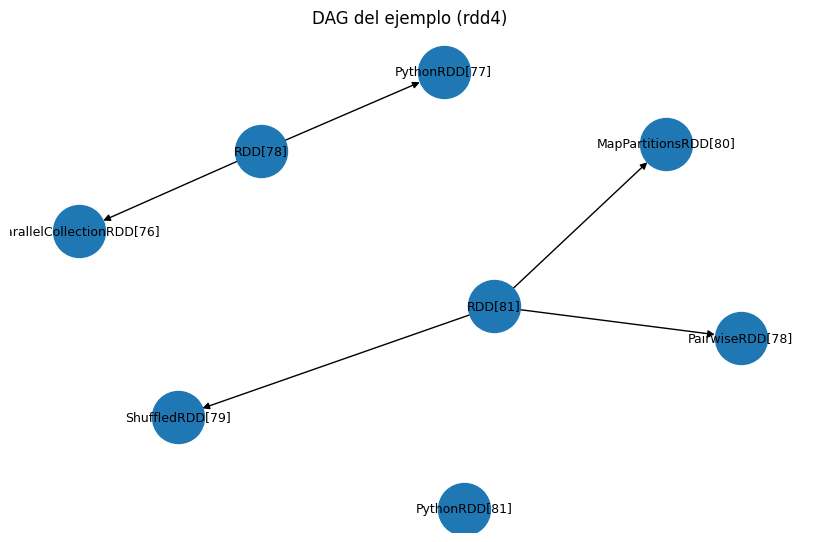

In [ ]:
# ============================================
# Visualización sencilla del DAG a partir de toDebugString
# - Parseamos el texto y dibujamos un grafo RDD_i -> RDD_j
# --- Visualización del DAG desde toDebugString (versión robusta) ---
# Este bloque construye un dibujito del DAG (linaje de RDDs) a partir del texto que devuelve toDebugString()
!pip -q install networkx

import re
import networkx as nx
import matplotlib.pyplot as plt
# networkx: para crear un grafo dirigido (nodos = RDDs, aristas = dependencias).
# re: expresiones regulares para extraer IDs y tipos de RDD del texto.
# matplotlib: para dibujar el grafo.

def _depth_from_prefix(line: str) -> int:
    """Aproxima la profundidad de indentación en toDebugString.
    Cuenta caracteres de prefijo como '|', '+', '-' y espacios."""
    prefix = re.match(r'^[\s\|\+\-]*', line).group(0)
    # Heurística: cada grupo de 2 espacios ó un símbolo cuenta 1 nivel
    # (no es perfecto, pero funciona bien en Spark 3.x)
    compact = prefix.replace('  ', '·')  # marca espacios dobles
    return compact.count('·') + prefix.count('|') + prefix.count('+') + prefix.count('-')
# toDebugString() indenta las líneas con |, +, - y espacios para mostrar jerarquía.
# Esta función estima la profundidad (nivel) del RDD leyendo ese prefijo.
# Sirve para saber quién es el padre inmediato de cada línea en el DAG.

def _extract_rdd_id_and_label(line: str):
    """Extrae (id, label) del tipo 'MapPartitionsRDD[6] ...' o 'ShuffledRDD[5] ...'."""
    m = re.search(r'([A-Za-z]+RDD)\[(\d+)\]', line)
    if m:
        rdd_type, rid = m.group(1), m.group(2)
        return rid, f'{rdd_type}[{rid}]'
    # Fallback para nombres menos comunes (ParallelCollectionRDD, PythonRDD, etc.)
    m2 = re.search(r'(\w+RDD)\[(\d+)\]', line)
    if m2:
        rdd_type, rid = m2.group(1), m2.group(2)
        return rid, f'{rdd_type}[{rid}]'
    # Último intento: 'RDD 7' (algunos builds)
    m3 = re.search(r'RDD\s+(\d+)', line)
    if m3:
        rid = m3.group(1)
        return rid, f'RDD[{rid}]'
    return None, None
# Busca patrones típicos del linaje:
# MapPartitionsRDD[62], ShuffledRDD[61], ParallelCollectionRDD[58], PythonRDD[...], etc.
# Devuelve (id, label) para cada RDD encontrado.
# Tiene fallbacks para formatos menos comunes, por eso es “robusta”.


def lineage_graph(rdd, title="DAG (RDD lineage)"):
    txt = rdd.toDebugString()
    if isinstance(txt, bytes):
        txt = txt.decode("utf-8")
    lines = [l.rstrip() for l in txt.splitlines() if l.strip()]

    nodes, edges = set(), []
    stack = []  # [(depth, rdd_id)]
# Obtiene el texto del linaje con toDebugString().
# Lo parte por líneas y prepara:
# nodes: etiquetas únicas de RDDs.
# edges: pares (padre → hijo).
# stack: una pila para reconstruir la jerarquía por profundidad.

    for ln in lines:
        rid, label = _extract_rdd_id_and_label(ln)
        if not rid:
            continue
        depth = _depth_from_prefix(ln)

        # mantener la pila en el nivel correcto
        while stack and stack[-1][0] >= depth:
            stack.pop()

        # si hay padre en la pila, conectamos padre -> actual
        if stack:
            parent_id = stack[-1][1]
            edges.append((f'RDD[{parent_id}]', label))

        nodes.add(label)
        stack.append((depth, rid))
# Extrae el ID/label del RDD.
# Calcula profundidad por indentación.
# Ajusta la pila: si subimos de nivel, “sacamos” padres hasta quedar en el padre correcto.
# Conecta el nodo actual con su padre (si existe).
# Agrega el nodo y lo apila como “último”.

    if not nodes:
        print("⚠️ No se detectaron nodos/edges. Muestro toDebugString para depurar:\n")
        print(txt)
        return

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=7)
    nx.draw(G, pos, with_labels=True, node_size=1400, font_size=9, arrows=True)
    plt.title(title)
    plt.show()
# Si no encontró nada, imprime el toDebugString() para depurar.
# Si encontró, crea el grafo dirigido y lo dibuja.

    # Ejemplo del bloque B
rdd0 = spark.sparkContext.parallelize(range(1, 11), 2)
rdd1 = rdd0.map(lambda x: (x % 3, x))
rdd2 = rdd1.filter(lambda kv: kv[1] > 3)
rdd3 = rdd2.reduceByKey(lambda a, b: a + b)   # wide dep -> shuffle -> nuevo stage
rdd4 = rdd3.mapValues(lambda s: s / 2)

_ = rdd4.collect()  # dispara el job
lineage_graph(rdd4, title="DAG del ejemplo (rdd4)")
# Se arma un pequeño pipeline con narrow deps (map, filter) y una wide dep (reduceByKey, que hace shuffle).
# Importante: se llama a una acción (collect()) antes de dibujar, para asegurar que Spark construya el DAG completo.
# lineage_graph(...) parsea el linaje de rdd4 y dibuja el grafo.

Ese gráfico es la visualización del DAG de RDDs que construyó Spark a partir de tu pipeline.
Qué representa el gráfico

Cada nodo = un RDD intermedio que Spark genera (por cada transformación).

Cada flecha = una dependencia entre RDDs (un RDD se construye a partir de otro).

El flujo va de izquierda a derecha (o de nodo a nodo según la disposición que networkx calculó).

Nodos principales que aparecen

ParallelCollectionRDD[76]

Es tu RDD inicial creado con parallelize(range(1,11),2).

Representa los datos base en 2 particiones.

PythonRDD[77] → RDD[78]

Aparecen cuando Spark aplica funciones Python (map(lambda...), etc.).

Son “envoltorios” para ejecutar tu código sobre los datos.

PairwiseRDD[78]

Es el RDD en formato (clave, valor) después del map(lambda x: (x % 3, x)).

MapPartitionsRDD[80]

Representa la transformación que se aplica partición por partición (ejemplo: mapValues).

ShuffledRDD[79]

Este es clave: aparece por el reduceByKey.

Indica que Spark tuvo que hacer un shuffle (redistribuir datos por clave entre particiones).

Cada vez que veas un ShuffledRDD, piensa: “Aquí empieza un nuevo stage en Spark”.

RDD[81] y PythonRDD[81]

Son los últimos RDDs después de aplicar la función de transformación final (mapValues(lambda s: s/2)).

PythonRDD[81] es el “RDD lógico final” que se materializa cuando hiciste .collect().

Cómo interpretarlo

Empieza en ParallelCollectionRDD[76] (los datos originales).

Se van aplicando transformaciones (map, filter, reduceByKey, mapValues), cada una creando un nuevo RDD en el grafo.

El grafo se “rompe” en ShuffledRDD[79] → eso marca un shuffle y, por tanto, la creación de un nuevo stage en el Job.

El nodo final PythonRDD[81] es el que se devuelve en la acción collect().

En resumen:
Ese gráfico es el “árbol genealógico” de tu RDD final. Te dice:

De dónde vienen los datos (ParallelCollectionRDD).

Qué transformaciones aplicaste (map, reduceByKey, mapValues).

Dónde Spark tuvo que hacer un shuffle (ShuffledRDD).

Qué RDD final se materializó cuando corriste la acción (PythonRDD[81]).

In [ ]:
# ============================================
# Distinguiendo narrow vs wide con tiempos y jobs
# ============================================
from time import perf_counter

def run_and_time(rdd, label):
    t0 = perf_counter()
    out = rdd.count()   # acción -> job
    t1 = perf_counter()
    print(f"{label}: count={out}, tiempo={t1 - t0:0.4f}s")
# perf_counter() toma tiempos de alta resolución.
#.count() es una acción: fuerza a Spark a ejecutar todo el DAG pendiente. También devuelve cuántos elementos tiene el RDD.
# Se imprime la etiqueta, el conteo y el tiempo invertido.

# Narrow chain (map -> filter): sin shuffle
rddA = spark.sparkContext.parallelize(list(range(1_000_00)), 4)
rddA_chain = rddA.map(lambda x: x*2).filter(lambda x: x % 3 == 0)
# range(1_000_00) = 100 000 (los guiones bajos son separadores visuales en Python).
# 4 particiones.
# map y filter son narrow dependencies: cada partición lee solo de su “padre” directo → no hay shuffle → suele ir en un solo stage.

# Wide op (groupByKey / reduceByKey): con shuffle
rddB = rddA.map(lambda x: (x % 100, x))
rddB_wide = rddB.reduceByKey(lambda a,b: a+b)
# Se crea un Pair RDD con claves x % 100.
# reduceByKey necesita agrupar por clave → redistribuye datos entre particiones (shuffle) → corte de stage (tendrás ≥2 stages en el job).
# Nota docente: reduceByKey es preferible a groupByKey porque combina localmente antes de barajar, reduce tráfico en el shuffle.

# Ejecutar y medir
run_and_time(rddA_chain, "NARROW cadena")
run_and_time(rddB_wide,  "WIDE reduceByKey (shuffle)")
# Cada llamada hace un .count() → un job por llamada.
# Esperable: la versión WIDE suele tardar más por el shuffle (serialización, red, disco).

# Abre el Spark UI y observa que la acción en rddB_wide crea >1 stages.
print("Spark UI:", spark.sparkContext.uiWebUrl)
# Ábrelo y comprueba:
# Para rddA_chain: un job con 1 stage (map+filter pipeline).
# Para rddB_wide: un job con ≥2 stages (antes y después del shuffle).
# Revisa en DAG Visualization dónde aparece el ShuffledRDD y cuántas tasks corren por stage.

# En resumen
# Narrow (map/filter): no mueve datos entre particiones → más barato.
# Wide (reduceByKey/join/groupByKey): requiere shuffle → nuevo stage, más costo.
# .count() se usa para forzar la ejecución y poder comparar tiempos reales.

NARROW cadena: count=33334, tiempo=0.5219s
WIDE reduceByKey (shuffle): count=100, tiempo=1.8470s
Spark UI: http://9a24a68b81e6:4040


1. NARROW cadena: count=33334, tiempo=0.5219s

Qué hizo:

Tomó el RDD de 100 000 números (range(100000)).

Aplicó map(x*2) → todos pares.

Luego filter(x % 3 == 0) → se quedan los múltiplos de 6.

Conteo:

De 100 000 elementos, solo 33 334 cumplen la condición (100000/3 ≈ 33333.3).

Por eso count=33334.

Tiempo (0.52s):

map + filter son narrow transformations.

No hubo shuffle, todo se resolvió dentro de cada partición → rápido, un solo stage.

2. WIDE reduceByKey (shuffle): count=100, tiempo=1.8470s

Qué hizo:

Transformó los números en pares (x % 100, x).

Así hay 100 claves posibles (0 a 99).

reduceByKey sumó los valores por clave → por eso el conteo final es 100.

Tiempo (1.85s):

reduceByKey es una wide transformation → necesita shuffle: mover datos entre particiones para agrupar por clave.

Esto implica más costo: serialización, red, disco, más de un stage.

Por eso tarda bastante más que la cadena narrow.

3. Spark UI: http://9a24a68b81e6:4040

Es la URL del Spark Web UI.

Allí podrías ver:

Que el job del NARROW tuvo 1 stage.

Que el job del WIDE tuvo ≥2 stages (antes y después del shuffle).

El DAG con un ShuffledRDD marcando dónde se cortó el pipeline.

En resumen:

count=33334 muestra el número de múltiplos de 6.

count=100 muestra que hay 100 claves distintas (0–99).

El tiempo extra del segundo se debe al shuffle.

El Spark UI te deja ver gráficamente cómo Spark dividió los trabajos en jobs/stages/tasks.

In [ ]:
# ============================================
# Dos acciones separadas -> dos jobs
# Este código está mostrando cómo cada acción en Spark dispara un Job independiente y cómo la persistencia (cache) evita recomputaciones.
# ============================================
rdd_base = spark.sparkContext.parallelize(range(1, 500001), 4)
rdd_proc  = rdd_base.map(lambda x: x*x).filter(lambda x: x % 5 == 0)
# rdd_base → contiene los números del 1 al 500 000, repartidos en 4 particiones.
# rdd_proc → transforma:
# map(lambda x: x*x) → calcula el cuadrado de cada número.
# filter(lambda x: x % 5 == 0) → se queda solo con los cuadrados divisibles por 5.
# Hasta aquí, nada se ejecuta todavía porque Spark aplica lazy evaluation.

# Job 1
print("take(5):", rdd_proc.take(5))   # acción -> job 1
# take(5) es una acción.
# Spark dispara un Job 1 que ejecuta map y filter sobre las particiones hasta encontrar 5 resultados.
# Ejemplo de salida:
# take(5): [25, 100, 225, 400, 625]

# Job 2
print("sum:", rdd_proc.sum())         # acción -> job 2
# sum() también es una acción, por lo que dispara un Job 2.
# Importante: Spark vuelve a recalcular todo el pipeline (map y filter sobre los 500 000 elementos) porque no recuerda el resultado de la acción anterior.
# Ejemplo de salida (no importa tanto el número exacto, sino que Spark recomputa)

# Persistir para reusar sin recomputar (mejor performance si se usa varias veces)
rdd_cached = rdd_proc.persist()
print("count (con cache):", rdd_cached.count())  # usa datos cacheados
# persist() (o .cache()) indica que los resultados intermedios de rdd_proc deben guardarse en memoria (o disco) después de la primera acción.
# La primera vez que ejecutas count(), Spark guarda los datos transformados.
# Si vuelves a usar rdd_cached en otra acción, Spark ya no recalcula desde cero, sino que lee del cache → mucho más rápido.

take(5): [25, 100, 225, 400, 625]
sum: 8333458333750000
count (con cache): 100000


1. take(5): [25, 100, 225, 400, 625]

El RDD rdd_proc es el resultado de:

rdd_base.map(lambda x: x*x).filter(lambda x: x % 5 == 0)


x*x → cuadrado de cada número.

filter(x % 5 == 0) → quedarse solo con los cuadrados divisibles por 5.

Los primeros 5 resultados que cumplen eso son:
5^2=25

10^2=100
15^2=225
20^2=400
25^22=625

Por eso aparece [25, 100, 225, 400, 625].

 2. sum: 8333458333750000

Aquí Spark recorrió todos los 500 000 números:

Los elevó al cuadrado.

Filtró los que son múltiplos de 5.

Sumó todos los valores resultantes.

El número exacto (8333458333750000) es el resultado de esa suma gigante.

Lo importante para fines de clase no es memorizar ese número, sino entender que Spark recalculó todo el pipeline (map + filter) para ejecutar el sum(), porque no estaba cacheado todavía.

3. count (con cache): 100000

Después de hacer .persist() sobre rdd_proc, Spark almacenó los resultados intermedios.

count() cuenta cuántos elementos tiene el RDD después de map y filter.

Significa que hay 100 000 números cuadrados divisibles por 5 entre 1² y 500 000².

Intuición: aproximadamente el 20% de los números hasta 500 000 son múltiplos de 5, y sus cuadrados también lo serán → por eso da 100 000.

En resumen:

take(5) → los primeros cuadrados múltiplos de 5.

sum → la suma total de todos esos cuadrados.

count (con cache) → cantidad total de elementos que cumplen la condición (100 000).

Además, al estar cacheado, Spark ya no recomputa el DAG completo, sino que usa los datos en memoria → mucho más eficiente.

In [ ]:
# ============================================
# Resumen didáctico en prints
# ============================================
print("""
CONCEPTOS CLAVE:
- RDD: colección distribuida inmutable.
- Transformación (lazy): map, filter, flatMap, distinct, sortBy, union, sample...
- Acción (ejecuta): collect, count, take, top, takeSample, sum, mean, stdev...
- Lazy evaluation: Spark arma un DAG y ejecuta recién cuando hay acción.
- Narrow dep.: no requiere shuffle (ej. map/filter) -> mismo stage.
- Wide dep.: requiere shuffle (ej. reduceByKey) -> corte de stage.
- Job: conjunto de stages disparados por una acción.
- Stage: grupo de tareas sin shuffles intermedios.
- Task: trabajo sobre una partición.
- Spark UI: escanea Jobs/Stages/Tasks y el DAG (URL arriba).
""")


CONCEPTOS CLAVE:
- RDD: colección distribuida inmutable.
- Transformación (lazy): map, filter, flatMap, distinct, sortBy, union, sample...
- Acción (ejecuta): collect, count, take, top, takeSample, sum, mean, stdev...
- Lazy evaluation: Spark arma un DAG y ejecuta recién cuando hay acción.
- Narrow dep.: no requiere shuffle (ej. map/filter) -> mismo stage.
- Wide dep.: requiere shuffle (ej. reduceByKey) -> corte de stage.
- Job: conjunto de stages disparados por una acción.
- Stage: grupo de tareas sin shuffles intermedios.
- Task: trabajo sobre una partición.
- Spark UI: escanea Jobs/Stages/Tasks y el DAG (URL arriba).

